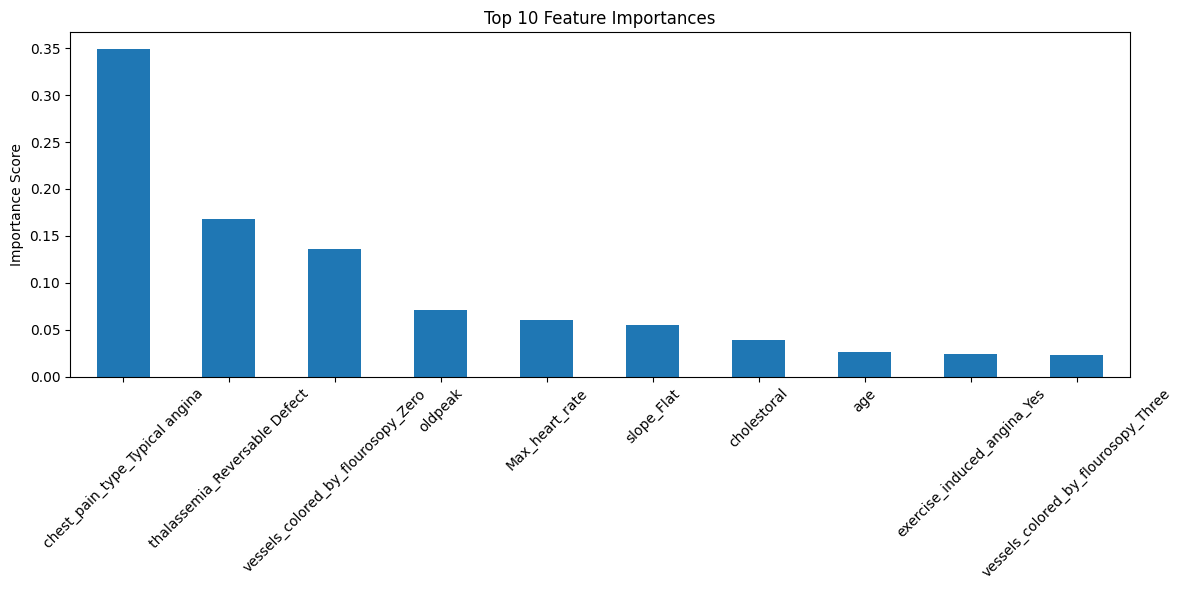

Feature Importance graph saved as PNG

Top 5 Features:
 Index(['chest_pain_type_Typical angina', 'thalassemia_Reversable Defect',
       'vessels_colored_by_flourosopy_Zero', 'oldpeak', 'Max_heart_rate'],
      dtype='object')

Accuracy using Top 5 Features: 0.7804878048780488


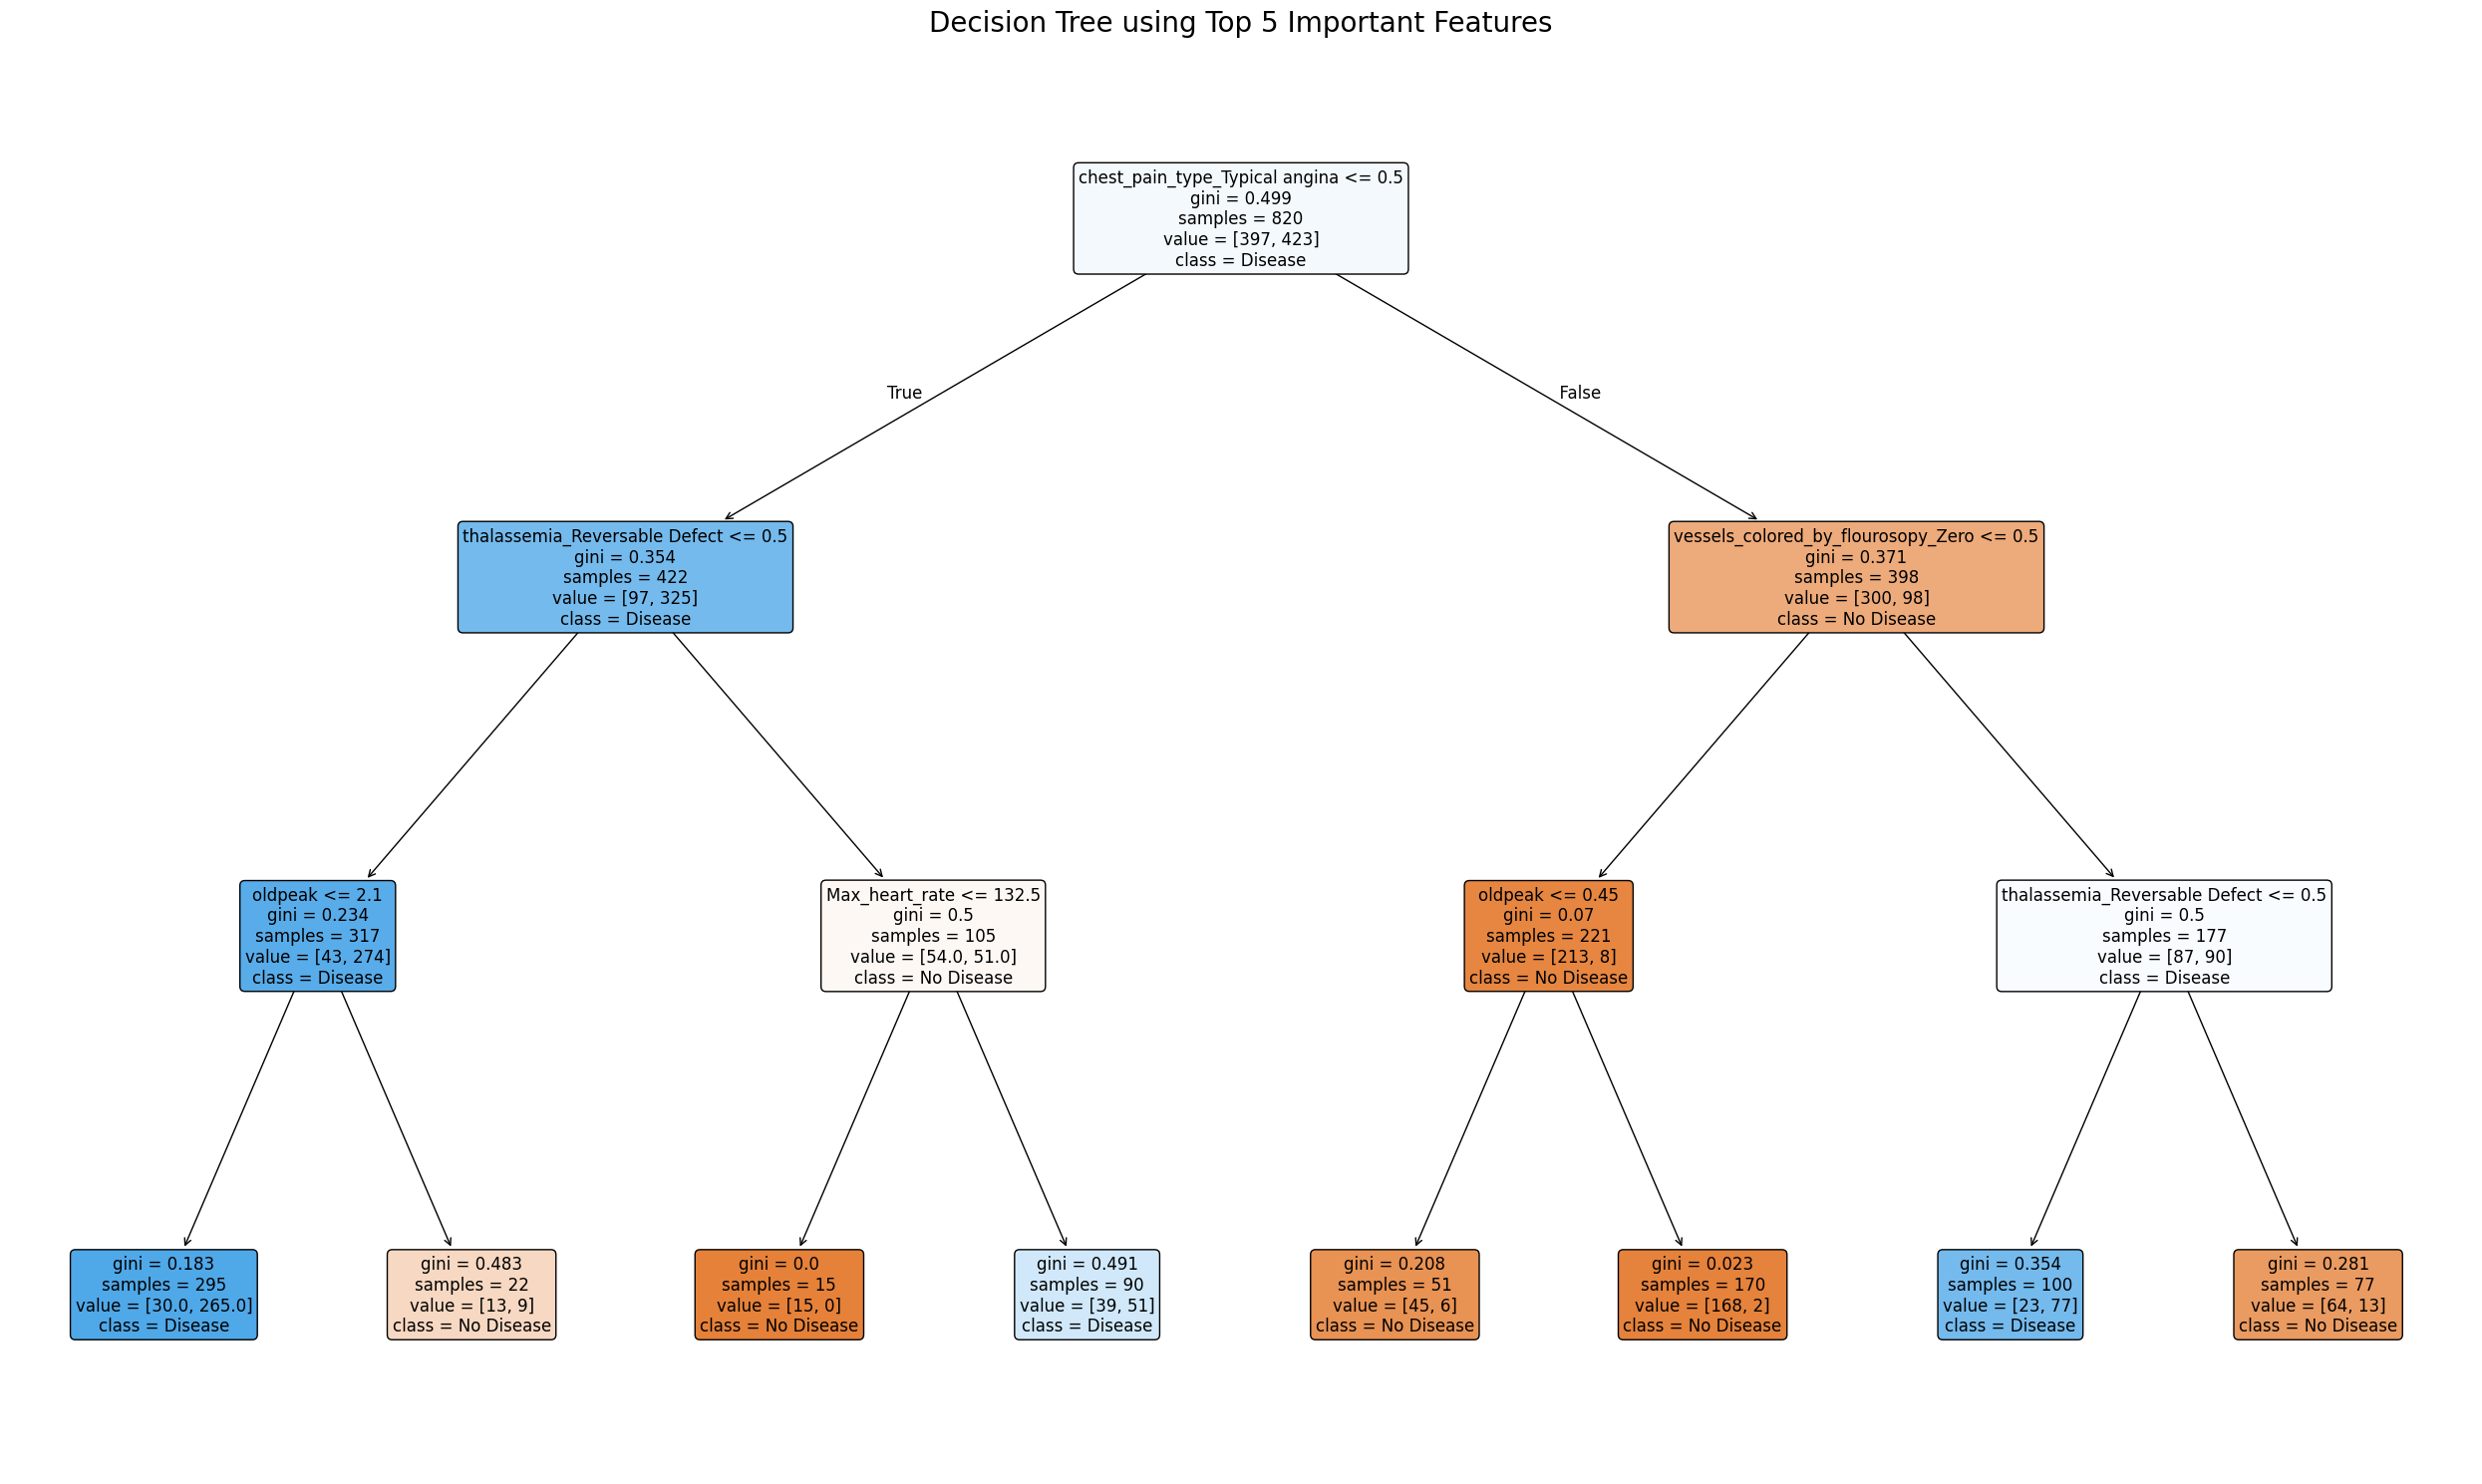

Decision Tree saved as PNG


In [1]:
# =====================================================
# HEART DISEASE PROJECT - PNG VERSION ONLY
# =====================================================

# 1️⃣ Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# =====================================================
# 2️⃣ Load Dataset
# =====================================================

df = pd.read_csv("heart.csv")

# Convert categorical columns
df = pd.get_dummies(df, drop_first=True)

# Define Features & Target
X = df.drop("target", axis=1)
y = df["target"]

# =====================================================
# 3️⃣ Train Initial Model (For Feature Importance)
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# =====================================================
# 4️⃣ Plot Feature Importance Graph
# =====================================================

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12,6))
importance.head(10).plot(kind='bar')

plt.title("Top 10 Feature Importances")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()

# Save ONLY PNG
plt.savefig("Feature_Importance.png", dpi=300)
plt.show()

print("Feature Importance graph saved as PNG")

# =====================================================
# 5️⃣ Select Top 5 Important Features
# =====================================================

top5_features = importance.head(5).index
print("\nTop 5 Features:\n", top5_features)

# =====================================================
# 6️⃣ Train Decision Tree with Top 5 Features
# =====================================================

X_top5 = X[top5_features]

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top5, y, test_size=0.2, random_state=42
)

model_top5 = DecisionTreeClassifier(max_depth=3, random_state=42)
model_top5.fit(X_train_top, y_train_top)

accuracy = accuracy_score(y_test_top, model_top5.predict(X_test_top))
print("\nAccuracy using Top 5 Features:", accuracy)

# =====================================================
# 7️⃣ Draw Decision Tree
# =====================================================

plt.figure(figsize=(25,15))

plot_tree(
    model_top5,
    feature_names=top5_features,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title("Decision Tree using Top 5 Important Features", fontsize=20)
plt.tight_layout()

# Save ONLY PNG
plt.savefig("Decision_Tree_Top5.png", dpi=300)
plt.show()

print("Decision Tree saved as PNG")